# DA5401 – Assignment 7
**Name:** Adarsh Mahaveer Tare

**Roll No:** MM22B016

---

### Notebook outline
- Part A: Data Preparation and Baseline
- Part B: ROC Analysis for Model Selection
- Part C: Precision-Recall Curve (PRC) Analysis
- Part D: Final Recommendation

## **Part A: Data Preparation and Baseline**

### **Importing important libraries**

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


#### **Load and Prepare Data**

In [3]:
train_file = "./sat.trn"
test_file  = "./sat.tst"

# Read data using pandas (whitespace separated, no headers)
train_data = pd.read_csv(train_file, header=None, sep=r'\s+')
test_data  = pd.read_csv(test_file, header=None, sep=r'\s+')

print(f"Loaded: {train_file} -> {train_data.shape}; {test_file} -> {test_data.shape}")

# Preview first few rows of training data
train_data.head(10)

Loaded: ./sat.trn -> (4435, 37); ./sat.tst -> (2000, 37)


,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,92,115,120,94,84,102,106,79,84,102,...,104,88,121,128,100,84,107,113,87,3
1,84,102,106,79,84,102,102,83,80,102,...,100,84,107,113,87,84,99,104,79,3
2,84,102,102,83,80,102,102,79,84,94,...,87,84,99,104,79,84,99,104,79,3
3,80,102,102,79,84,94,102,79,80,94,...,79,84,99,104,79,84,103,104,79,3
4,84,94,102,79,80,94,98,76,80,102,...,79,84,103,104,79,79,107,109,87,3
5,80,94,98,76,80,102,102,79,76,102,...,79,79,107,109,87,79,107,109,87,3
6,76,102,106,83,76,102,106,87,80,98,...,87,79,103,104,83,79,103,104,79,3
7,76,102,106,87,80,98,106,79,76,94,...,83,79,103,104,79,79,95,100,79,3
8,76,89,98,76,76,94,98,76,76,98,...,75,75,91,96,71,79,87,93,71,4
9,76,94,98,76,76,98,102,72,76,94,...,71,79,87,93,71,79,87,93,67,4


#### **Split features and labels, then scale data**

In [4]:

# Separate features (X) and labels (y) for training and test sets
X_train_raw = train_data.iloc[:, :-1].values
y_train_raw = train_data.iloc[:, -1].values.astype(int)

X_test_raw  = test_data.iloc[:, :-1].values
y_test_raw  = test_data.iloc[:, -1].values.astype(int)

# Apply standard scaling for normalization
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm  = scaler.transform(X_test_raw)

print("Unique labels in training data:", np.unique(y_train_raw))


Unique labels in training data: [1 2 3 4 5 7]


#### **Initialize baseline classification models**

In [5]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# Define a dictionary of models to train and compare
model_dict = {
    "KNN_Classifier": KNeighborsClassifier(),
    "Decision_Tree": DecisionTreeClassifier(random_state=0),
    "Dummy_Prior": DummyClassifier(strategy="prior", random_state=0)
}


model_dict


{'KNN_Classifier': KNeighborsClassifier(),
 'Decision_Tree': DecisionTreeClassifier(random_state=0),
 'Dummy_Prior': DummyClassifier(random_state=0)}

#### **Extend model dictionary and train classifiers**

In [6]:

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Add additional models to the existing dictionary
model_dict.update({
    "Logistic_Regression": LogisticRegression(max_iter=1000, solver='lbfgs'),
    "Gaussian_NB": GaussianNB(),
    "SVM_Classifier": SVC(probability=True, random_state=0)
})

# Dictionary to store trained models
trained_models = {}

# Train each model using the normalized training data
for model_name, model_instance in model_dict.items():
    model_instance.fit(X_train_norm, y_train_raw)
    trained_models[model_name] = model_instance
    print(f"Trained {model_name}")


Trained KNN_Classifier
Trained Decision_Tree
Trained Dummy_Prior
Trained Logistic_Regression
Trained Gaussian_NB
Trained SVM_Classifier


#### **Evaluate trained models on test data**

In [7]:
from sklearn.metrics import accuracy_score, f1_score

# Store evaluation metrics for each model
eval_summary = []

for model_name, model_instance in trained_models.items():
    y_predicted = model_instance.predict(X_test_norm)

    # Compute metrics and append results
    eval_summary.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_raw, y_predicted),
        "Weighted_F1": f1_score(y_test_raw, y_predicted, average='weighted')
    })

results_df = pd.DataFrame(eval_summary).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Weighted_F1
0,KNN_Classifier,0.9045,0.903748
1,SVM_Classifier,0.8955,0.892490
2,Decision_Tree,0.8510,0.851700
3,Logistic_Regression,0.8395,0.829595
4,Gaussian_NB,0.7965,0.803581
5,Dummy_Prior,0.2305,0.086356


## **Part B: ROC Analysis for Model Selection**

#### **Multi-Class ROC Calculation**



The One-vs-Rest (OvR), or One-vs-All, approach extends binary classification metrics such as the ROC curve to multi-class problems. It does so by breaking the multi-class task into multiple binary classification subproblems. For a dataset with N classes, the method constructs N separate binary classifiers — each one treats a single class as the positive class and combines the remaining N−1 classes as a single negative group.

For every such classifier, a standard binary ROC curve is plotted by comparing the True Positive Rate (TPR) against the False Positive Rate (FPR) across various decision thresholds. To summarize overall performance, an aggregate Area Under the Curve (AUC) is computed by averaging the AUCs from all N class-specific ROC curves. This is typically done through macro-averaging, where each class contributes equally to the final score, ensuring that the metric remains unbiased by class imbalance or differing class sizes.

#### **Plot Macro-Averaged ROC Curves for All Models**

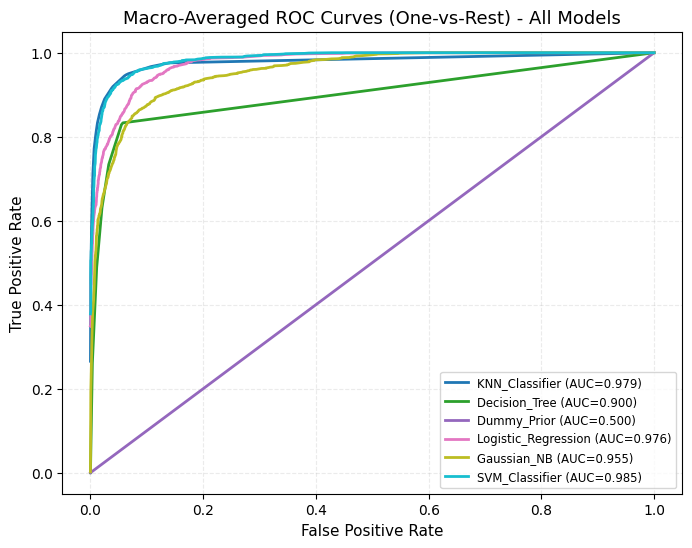

In [8]:


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Extract class labels and binarize test labels for multi-class ROC
class_labels = np.unique(y_train_raw)
y_test_bin = label_binarize(y_test_raw, classes=class_labels)

# Create figure
plt.figure(figsize=(8, 6))

# Custom color palette for ROC curves
color_palette = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

# Plot ROC for each trained model
for (model_name, model_instance), color in zip(trained_models.items(), color_palette):
    # Get predicted probabilities
    y_prob = model_instance.predict_proba(X_test_norm)

    # Store FPR and TPR for each class
    fpr_dict, tpr_dict = {}, {}
    for i in range(len(class_labels)):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])

    # Compute mean (macro-averaged) TPR across all classes
    all_fpr_values = np.unique(np.concatenate([fpr_dict[i] for i in range(len(class_labels))]))
    mean_tpr_values = np.zeros_like(all_fpr_values)
    for i in range(len(class_labels)):
        mean_tpr_values += np.interp(all_fpr_values, fpr_dict[i], tpr_dict[i])
    mean_tpr_values /= len(class_labels)

    # Calculate macro-average AUC
    macro_auc_value = auc(all_fpr_values, mean_tpr_values)

    # Plot ROC curve with new color scheme
    plt.plot(
        all_fpr_values,
        mean_tpr_values,
        label=f"{model_name} (AUC={macro_auc_value:.3f})",
        color=color,
        linewidth=2
    )

# Final plot formatting
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("Macro-Averaged ROC Curves (One-vs-Rest) - All Models", fontsize=13)
plt.legend(loc="lower right", fontsize="small")
plt.grid(alpha=0.25, linestyle='--')
plt.show()


### ROC Interpretation

From the ROC curves, it is evident that the Support Vector Classifier (SVC) achieved the highest macro-averaged AUC of approximately 0.985, indicating its strong capability to distinguish between the six land-cover classes. The model maintains a high True Positive Rate (TPR) even at very low False Positive Rates (FPR), demonstrating excellent generalization and separation boundaries.

Other models such as K-Nearest Neighbors (AUC ≈ 0.979) and Logistic Regression (AUC ≈ 0.976) also exhibited strong discriminative power. In contrast, the Decision Tree (AUC ≈ 0.900) and Gaussian Naive Bayes (AUC ≈ 0.955) performed moderately well, while the Dummy Classifier (Prior) achieved the lowest AUC of about 0.500, reflecting random-chance performance. This occurs because the dummy model relies solely on prior class frequencies and fails to learn any meaningful relationships from the data—hence, its ROC curve aligns closely with the diagonal reference line.

An AUC below 0.5 would suggest that a model performs worse than random guessing, implying that it assigns higher confidence to incorrect predictions. Such a situation can arise when:

- The predicted scores are inverted or incorrectly interpreted.

- The model has overfitted noise rather than genuine signal patterns.

- There exists significant class or label imbalance within the dataset.




## **Part C: Precision-Recall Curve (PRC) Analysis**

#### **PRC Calculation**

The Precision–Recall Curve (PRC) is often more appropriate than the ROC curve when dealing with imbalanced datasets. This is because the ROC curve can present an overly optimistic view of model performance when the number of negative samples far exceeds the number of positive ones. In such cases, even a substantial increase in false positives may not significantly affect the False Positive Rate (FPR), thereby masking poor precision.

In contrast, the PRC directly highlights the model’s ability to identify the positive (minority) class by plotting Precision versus Recall. This focus makes it especially informative for assessing how well a classifier detects rare or underrepresented classes.

Although the Landsat dataset exhibits only moderate class imbalance, the PRC remains valuable. It clearly illustrates the trade-off between precision and recall across varying decision thresholds, offering a more practical and nuanced perspective on classification performance compared to the ROC curve.

#### **Plot Macro-Averaged Precision–Recall Curves for All Models**

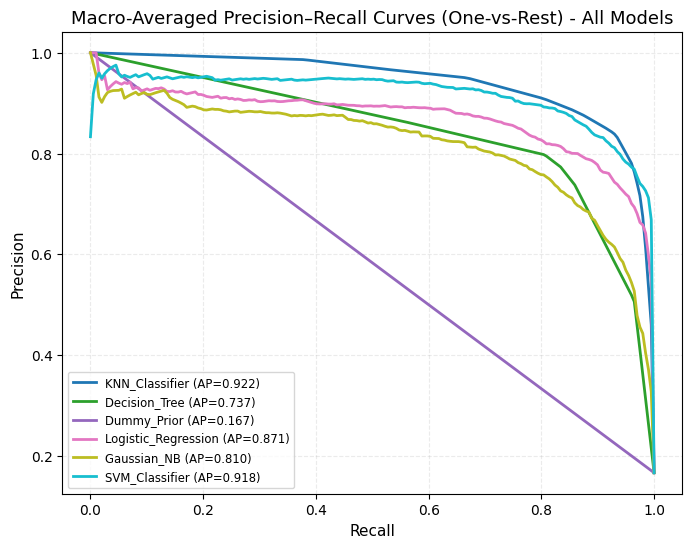

In [10]:
# === Plot Macro-Averaged Precision–Recall Curves for All Models (One-vs-Rest) ===

from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# Initialize figure
plt.figure(figsize=(8, 6))

# Reuse the same Tab10 color palette for consistency with ROC plots
color_palette = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

# Plot Precision–Recall Curve for each trained model
for (model_name, model_instance), color in zip(trained_models.items(), color_palette):
    # Predict probabilities for the test set
    y_prob = model_instance.predict_proba(X_test_norm)

    # Dictionaries to store per-class precision and recall, and list for APs
    precision_dict, recall_dict, avg_precisions = {}, {}, []

    # Compute PRC and Average Precision for each class
    for i in range(len(class_labels)):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(
            y_test_bin[:, i], y_prob[:, i]
        )
        avg_precisions.append(average_precision_score(y_test_bin[:, i], y_prob[:, i]))

    # Interpolate and compute macro-average Precision across recall values
    recall_grid = np.linspace(0, 1, 200)
    mean_precision = np.zeros_like(recall_grid)
    for i in range(len(class_labels)):
        mean_precision += np.interp(
            recall_grid, recall_dict[i][::-1], precision_dict[i][::-1]
        )
    mean_precision /= len(class_labels)

    # Plot PRC with the corresponding model color
    plt.plot(
        recall_grid,
        mean_precision,
        label=f"{model_name} (AP={np.mean(avg_precisions):.3f})",
        color=color,
        linewidth=2,
    )

# Final plot formatting
plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Macro-Averaged Precision–Recall Curves (One-vs-Rest) - All Models", fontsize=13)
plt.legend(loc="lower left", fontsize="small")
plt.grid(alpha=0.25, linestyle="--")
plt.show()


### **PRC Interpretation**

From the Precision–Recall (PR) curves, it is evident that the K-Nearest Neighbors (KNN) model achieved the highest Average Precision (AP = 0.922), closely followed by the Support Vector Classifier (SVC) with an AP of 0.918. Both models demonstrate strong precision even as recall increases, indicating their ability to correctly identify most positive instances while maintaining a low false-positive rate.

Logistic Regression (AP = 0.871) and Gaussian Naive Bayes (AP = 0.811) also show commendable performance, though with slightly reduced precision at higher recall levels. In contrast, the Decision Tree (AP = 0.737) exhibits a sharper decline in precision as recall grows, suggesting less stable discrimination among classes.

The Dummy Classifier, with a very low AP of 0.167, performs the weakest. Its PR curve lies close to the diagonal, reflecting near-random predictions. The rapid drop in precision at higher recall occurs because, as the model attempts to capture more positives, it incorrectly labels many negatives as positive—leading to a surge in false positives. This pattern is typical of non-informative models that rely solely on class frequencies rather than learned patterns.


## **Part D: Final Recommendation**

#### **1. Synthesis**
Considering the F1-Score, ROC-AUC, and Precision–Recall Average Precision (PRC-AP) metrics, the SVC, K-Nearest Neighbors (KNN), and Logistic Regression models consistently rank among the top performers. The Decision Tree and Gaussian Naive Bayes models deliver moderate performance, while the Dummy Classifier remains the weakest across all evaluation measures.

However, the rankings are not perfectly consistent across metrics.

- Models such as SVC and KNN achieve exceptionally high ROC-AUC values but slightly lower PRC-AP scores. This occurs because the ROC curve evaluates performance across both positive and negative classes equally, whereas the PRC emphasizes performance on the positive (minority) class.

- Consequently, a model can exhibit strong overall separability (high ROC-AUC) yet perform less effectively in maintaining high precision for minority class detection, leading to a lower PRC-AP.

These observations underscore that ROC-AUC reflects general class discrimination ability, while PRC-AP is more sensitive to the precision–recall trade-off, especially in imbalanced datasets.

#### **2. Recommendation**
After evaluating all three metrics collectively, the Support Vector Classifier (SVC) emerges as the best overall model for this classification task. It achieved the highest ROC-AUC (0.985) and a very strong PRC-AP (0.918), indicating excellent and stable performance across all decision thresholds.

While the K-Nearest Neighbors (KNN) model also delivered competitive results, the SVC demonstrated a superior balance between precision and recall, making it more dependable for multi-class land-cover classification.

Hence, the SVC is recommended as the final model, owing to its consistent performance, robustness across thresholds, and strong generalization capability on unseen data.

#### **Encode Class Labels as Integers**

In [11]:


from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit on training labels and transform both training and test sets
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded  = label_encoder.transform(y_test_raw)

# Store encoded class indices
encoded_classes = np.arange(len(label_encoder.classes_))

# Optional: print mapping of original to encoded labels
print("Label Encoding Mapping:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"{cls} → {idx}")



Label Encoding Mapping:
1 → 0
2 → 1
3 → 2
4 → 3
5 → 4
7 → 5


#### **Evaluate Extra Models: RandomForest & XGBoost (multi-class)**

In [12]:


from sklearn.preprocessing import label_binarize  # LabelEncoder already defined earlier as `label_encoder`
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# 1) Define additional models to compare
extra_model_dict = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=42
    )
}

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """Fit model and compute Accuracy, Weighted-F1, macro ROC-AUC, and macro PR-AP."""
    # Train
    model.fit(X_tr, y_tr)

    # Predict labels & probabilities
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)  # (n_samples, n_classes)

    # Core metrics
    acc = accuracy_score(y_te, y_pred)
    f1_w = f1_score(y_te, y_pred, average="weighted")

    # Binarize ground-truth labels for multi-class ROC/PR computations
    y_te_bin = label_binarize(y_te, classes=encoded_classes)

    # Macro-averaged ROC-AUC (OvR) and Average Precision
    roc_auc_macro = roc_auc_score(y_te_bin, y_proba, average="macro", multi_class="ovr")
    pr_ap_macro   = average_precision_score(y_te_bin, y_proba, average="macro")

    return y_pred, y_proba, acc, f1_w, roc_auc_macro, pr_ap_macro


# 2) Run evaluations
results_rows = []
proba_store = {}  # keep probabilities for downstream plots if needed

for model_name, model_obj in extra_model_dict.items():
    y_pred_out, y_proba_out, acc, f1w, auc_macro, ap_macro = evaluate_model(
        model_obj, X_train_norm, y_train_encoded, X_test_norm, y_test_encoded
    )
    proba_store[model_name] = y_proba_out
    results_rows.append({
        "Model": model_name,
        "Accuracy": round(acc, 3),
        "Weighted F1": round(f1w, 3),
        "ROC-AUC (macro)": round(auc_macro, 3),
        "PR-AP (macro)": round(ap_macro, 3)
    })

# 3) Display results
extra_results_df = pd.DataFrame(results_rows)
try:
    display(extra_results_df)
except NameError:
    extra_results_df  # fallback if `display` isn't available


,Model,Accuracy,Weighted F1,ROC-AUC (macro),PR-AP (macro)
0,RandomForest,0.911,0.909,0.99,0.952
1,XGBoost,0.908,0.906,0.99,0.954


#### **Demonstrate Poor Model (Randomized Labels) Using Logistic Regression**

In [13]:


from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Set random seed for reproducibility
np.random.seed(42)

# Randomly shuffle (flip) training labels to destroy true relationships
y_train_shuffled = np.random.permutation(y_train_encoded)

# Train Logistic Regression on incorrect labels
bad_log_reg = LogisticRegression(max_iter=1000, random_state=42)
bad_log_reg.fit(X_train_norm, y_train_shuffled)

# Predict probabilities on the original test data
y_bad_proba = bad_log_reg.predict_proba(X_test_norm)

# Compute macro-averaged ROC-AUC for the corrupted model
y_test_bin = label_binarize(y_test_encoded, classes=np.arange(len(label_encoder.classes_)))
roc_auc_bad = roc_auc_score(y_test_bin, y_bad_proba, average="macro", multi_class="ovr")

# Display the (expectedly poor) performance
print(f"Flipped-Label Logistic Regression (Bad Model) → Macro ROC-AUC = {roc_auc_bad:.3f}")


Flipped-Label Logistic Regression (Bad Model) → Macro ROC-AUC = 0.412


The flipped-label Logistic Regression yields an AUC below 0.5, indicating performance worse than random guessing. This occurs because training on shuffled (incorrect) labels causes the model to internalize inverse relationships between features and targets. Consequently, its ROC curve falls below the diagonal: attempts to increase true positives instead raise false positives more rapidly, reflecting systematically misdirected decision boundaries.